<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day11_practice1_YOLO_%ED%8F%AC%EB%A7%B7_%ED%95%B4%EB%B6%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# YOLO 데이터셋 포맷 해부 - 라벨을 눈으로 검증
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 4.2 MB/s eta 0:00:00


In [2]:
import os, glob # glob=파일 패턴 검색
import matplotlib.pyplot as plt
import matplotlib.patches as patches # 도형그리기
from PIL import Image                # Pillow 이미지 열기/ 크기 확인

In [3]:
import os
from ultralytics.data.utils import check_det_dataset  # 학습 없이 데이터셋 다운로드 + 검사만 수행하는 유형
info = check_det_dataset("coco8.yaml")  # 데이터셋 정보 딕셔너리 반환
print(info["train"])  # train: 학습용 이미지 경로
DATA_DIR = os.path.dirname(info["train"]).rsplit("/images", 1)[0]
print("데이터셋 위치:", DATA_DIR)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 939.2files/s 0.0s
Dataset download success ✅ (0.7s), saved to /content/datasets

/content/datasets/coco8/images/train
데이터셋 위치: /content/datasets/coco8


In [4]:
# 셀 1. 폴더 구조
for split in ["train", "val"]:
  imgs = glob.glob(f"{DATA_DIR}/images/{split}/") # glob(패턴): 패턴에 맞는 파일 경로 리스트
  lbls = glob.glob(f"{DATA_DIR}/labels/{split}/")
  print(f"{split}: 이미지 {len(imgs)}장 / 라벨 {len(lbls)}개")

  # 라벨이 없는 사진 = "물체 없음"으로 취급

train: 이미지 1장 / 라벨 1개
val: 이미지 1장 / 라벨 1개


In [5]:
# 셀 2. YOLO 라벨 파일(txt) 형식
label_files = sorted(glob.glob(f"{DATA_DIR}/labels/train/*.txt"))
sample_label = label_files[0]
print(f"\n라벨 파일: {os.path.basename(sample_label)}") # 경로에서 파일명만 뽑음
print(open(sample_label).read().strip())               # 파일 전체를 문자열로 읽음
# 클래스번호 중심x 중심y 너비 높이  (전부 0-1 비율)


라벨 파일: 000000000009.txt
45 0.479492 0.688771 0.955609 0.5955
45 0.736516 0.247188 0.498875 0.476417
50 0.637063 0.732938 0.494125 0.510583
45 0.339438 0.418896 0.678875 0.7815
49 0.646836 0.132552 0.118047 0.0969375
49 0.773148 0.129802 0.0907344 0.0972292
49 0.668297 0.226906 0.131281 0.146896
49 0.642859 0.0792187 0.148063 0.148062


In [6]:
print(info["names"])

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

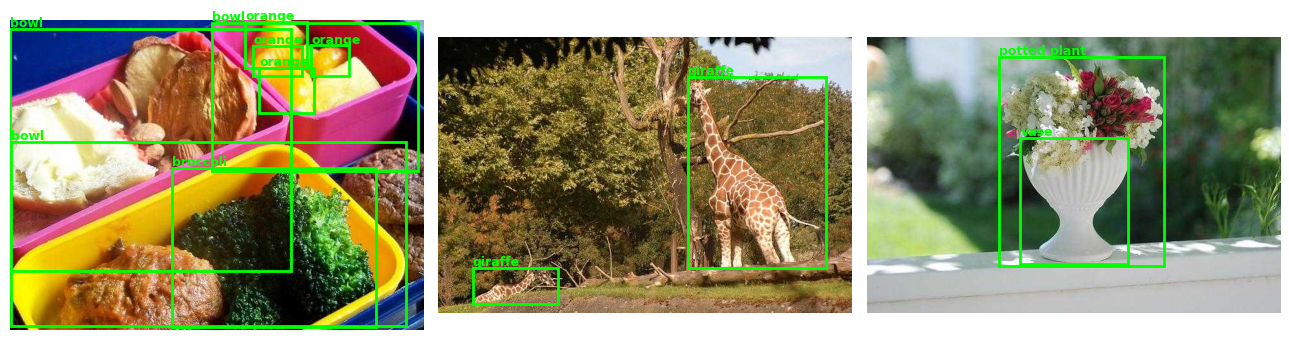

In [7]:
# 셀 3. 라벨 시각화 - 학습 전 반드시 하는 검증
# '라벨이 박스를 제대로 가리키는가'를 눈으로 확인

names = info["names"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
img_files = sorted(glob.glob(f"{DATA_DIR}/images/train/*"))
for ax, img_path in zip(axes, img_files[:3]):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    ax.axis("off")
    lbl_path = img_path.replace("/images/", "/labels/").rsplit(".", 1)[0] + ".txt"
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            cls, cx, cy, w, h = map(float, line.split())
            x1 = (cx - w / 2) * W
            y1 = (cy - h / 2) * H
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1),
                    w * W,
                    h * H,
                    fill=False,
                    color="lime",
                    lw=2
                )
            )
            ax.text(
                x1,
                y1 - 4,
                names[int(cls)],
                color="lime",
                fontsize=9,
                weight="bold"
            )
plt.tight_layout()
plt.savefig("plot_labels.png")
plt.show()

In [9]:
# 셀 4. data.yaml

# 1. 폴더를 ZIP 으로 압축
!zip -r /content/datasets/coco8.zip /content/datasets/coco8

# 2. ZIP 파일 다운로드
from google.colab import files
files.download('/content/datasets/coco8.zip')

  adding: content/datasets/coco8/ (stored 0%)
  adding: content/datasets/coco8/README.md (deflated 49%)
  adding: content/datasets/coco8/labels/ (stored 0%)
  adding: content/datasets/coco8/labels/val/ (stored 0%)
  adding: content/datasets/coco8/labels/val/000000000049.txt (deflated 52%)
  adding: content/datasets/coco8/labels/val/000000000042.txt (deflated 9%)
  adding: content/datasets/coco8/labels/val/000000000036.txt (deflated 27%)
  adding: content/datasets/coco8/labels/val/000000000061.txt (deflated 47%)
  adding: content/datasets/coco8/labels/train/ (stored 0%)
  adding: content/datasets/coco8/labels/train/000000000009.txt (deflated 52%)
  adding: content/datasets/coco8/labels/train/000000000030.txt (deflated 28%)
  adding: content/datasets/coco8/labels/train/000000000025.txt (deflated 27%)
  adding: content/datasets/coco8/labels/train/000000000034.txt (deflated 10%)
  adding: content/datasets/coco8/LICENSE (deflated 66%)
  adding: content/datasets/coco8/images/ (stored 0%)
  a

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>